# Synthetic Lending Portfolio: From Payments to Delinquency
**A reproducible Python playbook by Wael El Ghazzawi**

Build a fictional loan portfolio, simulate monthly payment events, and calculate overdue-payment metrics without confusing scheduled balances with an accounting ledger.

**What you will learn**
1. Calculate amortizing payments, including the zero-interest case.
2. Allocate payments to the oldest unpaid installment and derive days past due (DPD).
3. Compare account-level and scheduled-exposure-weighted delinquency.
4. Build migration and vintage views with appropriate denominators.
5. Export documented data and verify reproducibility.

### Provenance and intended use
All records are generated from scratch with a fixed seed. No customer, employer, credit-bureau, or proprietary data is used. Amounts are fictional **USD**. The payment probabilities and segment relationships are hand-set teaching assumptions, not empirical estimates. These data cannot establish real default risk, fairness, pricing, or model quality.

This is a payment-allocation teaching simulation, **not** a servicing ledger. It has no fees, penalties, prepayments, charge-offs, recoveries, or daily interest accrual. `scheduled_principal_usd` is the contractual balance assuming on-time payments, **not the actual outstanding principal**. A 90+ DPD observation is not a legal default determination.

The notebook was developed with OpenAI Codex assistance. Its outputs are checked by executable assertions below; that does not validate the assumptions against real lending data.

**Runtime:** Python 3.10+, NumPy, pandas, Matplotlib. CPU only; no internet, credentials, cloud services, or paid APIs required. Run all cells in order. Outputs go to `/kaggle/working/synthetic_lending` on Kaggle, or `./synthetic_lending` elsewhere.

**License:** notebook and generated dataset: CC0-1.0. Dependency licenses remain their own.

In [1]:
from pathlib import Path
from collections import deque
import calendar
import hashlib
import json
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

SEED = 20260922
N_LOANS = 1500
AS_OF = pd.Timestamp("2026-08-31")
OUTPUT = (Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()) / "synthetic_lending"
OUTPUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
print({"python": platform.python_version(), "numpy": np.__version__,
       "pandas": pd.__version__, "matplotlib": matplotlib.__version__, "seed": SEED})

{'python': '3.14.7', 'numpy': '2.5.3', 'pandas': '3.0.6', 'matplotlib': '3.11.2', 'seed': 20260922}


## 1. Contractual repayment schedule
For principal $P$, monthly rate $r$, and $n$ installments, the level payment is
$$A = \frac{Pr}{1-(1+r)^{-n}}.$$
When $r=0$, use $P/n$. We retain full floating-point precision in calculations; displayed amounts are rounded. Production accounting would require an explicit currency-rounding policy and final-payment adjustment.

Here `annual_rate` is a nominal annual contract rate divided by 12, not a fee-inclusive effective APR.

In [2]:
def monthly_payment(principal, annual_rate, term_months):
    if not np.isfinite(principal) or principal <= 0:
        raise ValueError("principal must be finite and positive")
    if not np.isfinite(annual_rate) or annual_rate < 0:
        raise ValueError("annual_rate must be finite and nonnegative")
    if not isinstance(term_months, (int, np.integer)) or term_months <= 0:
        raise ValueError("term_months must be a positive integer")
    r = annual_rate / 12
    return principal / term_months if r == 0 else principal * r / (-np.expm1(-term_months * np.log1p(r)))

def scheduled_balance(principal, annual_rate, term_months, installments_elapsed):
    if not 0 <= installments_elapsed <= term_months:
        raise ValueError("installments_elapsed must be within the contract term")
    payment = monthly_payment(principal, annual_rate, term_months)
    r = annual_rate / 12
    if r == 0:
        return max(0.0, principal - payment * installments_elapsed)
    growth_minus_one = np.expm1(installments_elapsed * np.log1p(r))
    return max(0.0, principal * (1 + growth_minus_one) - payment * growth_minus_one / r)

assert np.isclose(monthly_payment(1200, 0, 12), 100)
assert np.isclose(scheduled_balance(1200, 0, 12, 6), 600)
assert np.isclose(monthly_payment(1000, 0.12, 1), 1010)
for rate in [0.0, 1e-10, 0.06, 0.24]:
    payment = monthly_payment(10000, rate, 36)
    balance = 10000.0
    for k in range(1, 37):
        balance = balance * (1 + rate / 12) - payment
        assert np.isclose(balance, scheduled_balance(10000, rate, 36, k), atol=1e-6)
    assert abs(balance) < 1e-6
for args in [(0, 0.1, 12), (1000, -0.1, 12), (1000, 0.1, 0)]:
    try:
        monthly_payment(*args)
    except ValueError:
        pass
    else:
        raise AssertionError("Invalid input was accepted")
print("Amortization and input-validation tests passed.")

Amortization and input-validation tests passed.


## 2. Simulate payments, then derive delinquency
Each fictional loan starts 6–24 monthly installments before the cutoff. Contracts last 36, 48, or 60 months, so every loan is still contractually active at the cutoff.

Every due date is month-end. At each month-end we:
1. Add the newly due installment to an unpaid queue.
2. Draw a payment of zero to three whole installments, capped at the amount due.
3. Allocate payment to the oldest installment first.
4. Measure DPD from the oldest unpaid due date.

An installment missed **today** has DPD 0 until tomorrow. `unpaid_installments > 0` therefore differs from `dpd > 0`. Status buckets are `Current / due today`, `1–29`, `30–59`, `60–89`, and `90+`. Calendar-month lengths matter; we do not assume every missed month equals exactly 30 days.

The segment labels describe simulation settings, not actual borrower risk grades. Repayment probabilities intentionally differ by segment. A common seasonal reduction is also hand-set; neither feature is evidence about real borrowers.

In [3]:
SEGMENTS = ["Scenario A", "Scenario B", "Scenario C"]
PAY_PROB = {"Scenario A": 0.96, "Scenario B": 0.88, "Scenario C": 0.76}
BUCKETS = ["Current / due today", "1–29", "30–59", "60–89", "90+"]

def month_end(period):
    return pd.Timestamp(period.year, period.month, calendar.monthrange(period.year, period.month)[1])

def apply_payment(unpaid, due_date, requested_installments):
    unpaid.append(due_date)
    paid = min(requested_installments, len(unpaid))
    for _ in range(paid):
        unpaid.popleft()
    dpd = (due_date - unpaid[0]).days if unpaid else 0
    return paid, dpd

def generate_portfolio(n_loans=N_LOANS, seed=SEED):
    rng = np.random.default_rng(seed)
    loans, observations = [], []
    cutoff_period = AS_OF.to_period("M")
    for i in range(n_loans):
        loan_id = f"SYN-{i+1:06d}"
        age = int(rng.integers(6, 25))
        orig_period = cutoff_period - age
        segment = str(rng.choice(SEGMENTS, p=[0.45, 0.35, 0.20]))
        principal = float(rng.integers(20, 401) * 250)
        annual_rate = float(rng.choice([0.0, 0.06, 0.12, 0.18]))
        term = int(rng.choice([36, 48, 60]))
        payment = monthly_payment(principal, annual_rate, term)
        loans.append({"loan_id": loan_id, "origination_date": month_end(orig_period),
                      "segment": segment, "principal_usd": principal,
                      "annual_rate": annual_rate, "term_months": term,
                      "monthly_payment_usd": payment})
        unpaid = deque()
        for mob in range(1, age + 1):
            due = month_end(orig_period + mob)
            p = PAY_PROB[segment] - (0.06 if due.month in [1, 2] else 0.0)
            requested = 0
            if rng.random() < p:
                requested = 1
                if unpaid and rng.random() < 0.55:
                    requested += int(rng.integers(1, 3))
            paid, dpd = apply_payment(unpaid, due, requested)
            observations.append({"loan_id": loan_id, "observation_date": due,
                                 "months_on_book": mob, "installments_paid": paid,
                                 "payment_received_usd": paid * payment,
                                 "unpaid_installments": len(unpaid),
                                 "oldest_unpaid_due_date": unpaid[0] if unpaid else pd.NaT,
                                 "overdue_scheduled_amount_usd": len(unpaid) * payment,
                                 "dpd": dpd,
                                 "scheduled_principal_usd": scheduled_balance(principal, annual_rate, term, mob)})
    return pd.DataFrame(loans), pd.DataFrame(observations)

loans, performance = generate_portfolio()
performance["dpd_bucket"] = pd.cut(performance.dpd, [-1, 0, 29, 59, 89, np.inf], labels=BUCKETS)
print(f"{len(loans):,} fictional loans; {len(performance):,} monthly observations")
display(loans.head())
display(performance.head())

1,500 fictional loans; 22,743 monthly observations


,loan_id,origination_date,segment,principal_usd,annual_rate,term_months,monthly_payment_usd
0,SYN-000001,2025-01-31,Scenario C,99250.0,0.18,48,2915.468711
1,SYN-000002,2024-09-30,Scenario A,23500.0,0.18,48,690.312491
2,SYN-000003,2024-08-31,Scenario A,18500.0,0.18,36,668.819317
3,SYN-000004,2024-08-31,Scenario A,49000.0,0.18,60,1244.277944
4,SYN-000005,2024-12-31,Scenario C,55250.0,0.18,36,1997.419853


,loan_id,observation_date,months_on_book,installments_paid,payment_received_usd,unpaid_installments,oldest_unpaid_due_date,overdue_scheduled_amount_usd,dpd,scheduled_principal_usd,dpd_bucket
0,SYN-000001,2025-02-28,1,1,2915.468711,0,NaT,0.000000,0,97823.281289,Current / due today
1,SYN-000001,2025-03-31,2,1,2915.468711,0,NaT,0.000000,0,96375.161797,Current / due today
2,SYN-000001,2025-04-30,3,0,0.000000,1,2025-04-30,2915.468711,0,94905.320513,Current / due today
3,SYN-000001,2025-05-31,4,2,5830.937422,0,NaT,0.000000,0,93413.431610,Current / due today
4,SYN-000001,2025-06-30,5,1,2915.468711,0,NaT,0.000000,0,91899.164373,Current / due today


## 3. Check the data contract
Tests below verify keys, payment conservation, queue behavior, calendar DPD, and reproducibility. They deliberately test a missed February installment followed by a catch-up payment. A second complete simulation with the same seed must produce identical tables.

In [4]:
queue = deque()
assert apply_payment(queue, pd.Timestamp("2026-01-31"), 0) == (0, 0)
assert apply_payment(queue, pd.Timestamp("2026-02-28"), 0) == (0, 28)
assert apply_payment(queue, pd.Timestamp("2026-03-31"), 1) == (1, 31)
assert apply_payment(queue, pd.Timestamp("2026-04-30"), 3) == (3, 0)
assert len(queue) == 0

assert loans.loan_id.is_unique and len(loans) == N_LOANS
assert not performance.duplicated(["loan_id", "observation_date"]).any()
assert set(performance.loan_id) == set(loans.loan_id)
assert performance.observation_date.max() == AS_OF
assert performance.dpd.ge(0).all()
joined = performance.merge(loans, on="loan_id", validate="many_to_one")
assert (joined.observation_date > joined.origination_date).all()
assert (joined.months_on_book < joined.term_months).all()
assert np.allclose(joined.payment_received_usd, joined.installments_paid * joined.monthly_payment_usd)
assert np.allclose(joined.overdue_scheduled_amount_usd, joined.unpaid_installments * joined.monthly_payment_usd)
paid_to_date = performance.groupby("loan_id", sort=False).installments_paid.cumsum()
assert np.array_equal(performance.unpaid_installments, performance.months_on_book - paid_to_date)
assert performance.unpaid_installments.ge(0).all()
expected_dpd = (performance.observation_date - performance.oldest_unpaid_due_date).dt.days.fillna(0)
assert np.array_equal(performance.dpd, expected_dpd)
assert (performance.oldest_unpaid_due_date.isna() == performance.unpaid_installments.eq(0)).all()
assert (joined.scheduled_principal_usd >= -1e-7).all()
assert (joined.scheduled_principal_usd <= joined.principal_usd + 1e-7).all()
assert performance.groupby("loan_id").scheduled_principal_usd.diff().dropna().le(1e-6).all()
loans_again, performance_again = generate_portfolio()
pd.testing.assert_frame_equal(loans, loans_again)
pd.testing.assert_frame_equal(performance.drop(columns="dpd_bucket"), performance_again)
print("All data integrity, payment-allocation, and reproducibility tests passed.")

All data integrity, payment-allocation, and reproducibility tests passed.


## 4. Portfolio snapshot: choose the denominator
We take exactly one record per loan at the cutoff. DPD30+ means `dpd >= 30`.

- **Account rate:** number of DPD30+ accounts / all accounts at the cutoff.
- **Scheduled-exposure-weighted rate:** sum of contractual scheduled principal on DPD30+ accounts / scheduled principal on all accounts.

The second metric is a **teaching proxy**, not accounting PAR30. Because delinquent payments do not alter the contractual schedule here, it cannot substitute for actual principal-at-risk reporting. Differences between these rates reflect account sizes and amortization, not necessarily worsening risk.

,metric,value
0,Accounts,1.500000e+03
1,Original principal USD,7.921700e+07
2,Scheduled principal USD (proxy),5.578565e+07
3,DPD30+ account rate,5.530000e-02
4,DPD30+ scheduled-weighted rate (proxy),4.920000e-02
5,DPD90+ account rate,4.700000e-03


,accounts,dpd30_accounts,scheduled_principal_usd,dpd30_account_rate
segment,,,,
Scenario A,668,5,2.401901e+07,0.0075
Scenario B,542,33,2.068508e+07,0.0609
Scenario C,290,45,1.108157e+07,0.1552


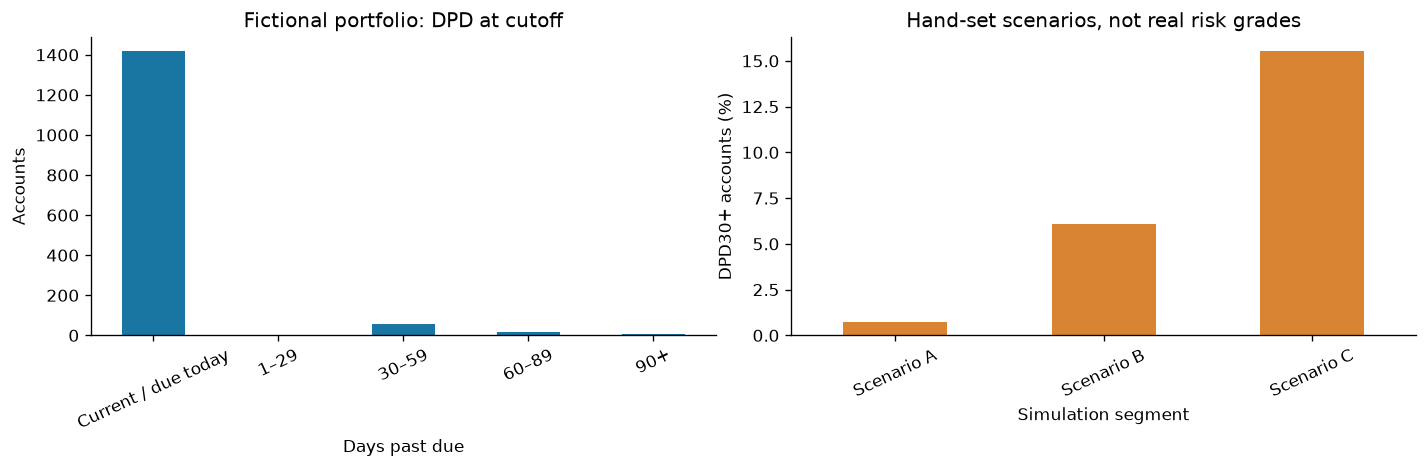

In [5]:
snapshot = joined.loc[joined.observation_date.eq(AS_OF)].copy()
assert len(snapshot) == N_LOANS and snapshot.loan_id.is_unique
snapshot["dpd30_plus"] = snapshot.dpd.ge(30)
account_rate = snapshot.dpd30_plus.mean()
weighted_rate = np.average(snapshot.dpd30_plus, weights=snapshot.scheduled_principal_usd)
summary = pd.DataFrame({"metric": ["Accounts", "Original principal USD", "Scheduled principal USD (proxy)",
                                   "DPD30+ account rate", "DPD30+ scheduled-weighted rate (proxy)", "DPD90+ account rate"],
                        "value": [len(snapshot), snapshot.principal_usd.sum(), snapshot.scheduled_principal_usd.sum(),
                                  account_rate, weighted_rate, snapshot.dpd.ge(90).mean()]})
display(summary.round(4))
segment_summary = snapshot.groupby("segment", observed=True).agg(
    accounts=("loan_id", "size"), dpd30_accounts=("dpd30_plus", "sum"),
    scheduled_principal_usd=("scheduled_principal_usd", "sum"))
segment_summary["dpd30_account_rate"] = segment_summary.dpd30_accounts / segment_summary.accounts
assert segment_summary.accounts.sum() == N_LOANS
assert np.isclose(np.average(segment_summary.dpd30_account_rate, weights=segment_summary.accounts), account_rate)
display(segment_summary.round(4))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
snapshot.dpd_bucket.value_counts(sort=False).reindex(BUCKETS).plot.bar(ax=axes[0], color="#1976A3")
axes[0].set(title="Fictional portfolio: DPD at cutoff", ylabel="Accounts", xlabel="Days past due")
segment_summary.dpd30_account_rate.mul(100).plot.bar(ax=axes[1], color="#D88432")
axes[1].set(title="Hand-set scenarios, not real risk grades", ylabel="DPD30+ accounts (%)", xlabel="Simulation segment")
for ax in axes: ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(OUTPUT / "portfolio_snapshot.png", bbox_inches="tight")
plt.show()

## 5. Month-to-month migration
A transition is counted only when both adjacent monthly observations exist. Each eligible adjacent pair is one observation: loans with longer histories contribute more pairs. This pooled matrix is not a one-period portfolio forecast.

The first observation of a loan has no prior state and is excluded. Counts accompany percentages so small samples are visible.

dpd_bucket,Current / due today,1–29,30–59,60–89,90+
previous_bucket,,,,,
Current / due today,19741,62,407,0,0
1–29,38,0,55,0,0
30–59,306,27,245,110,1
60–89,42,1,27,62,33
90+,0,3,12,12,59


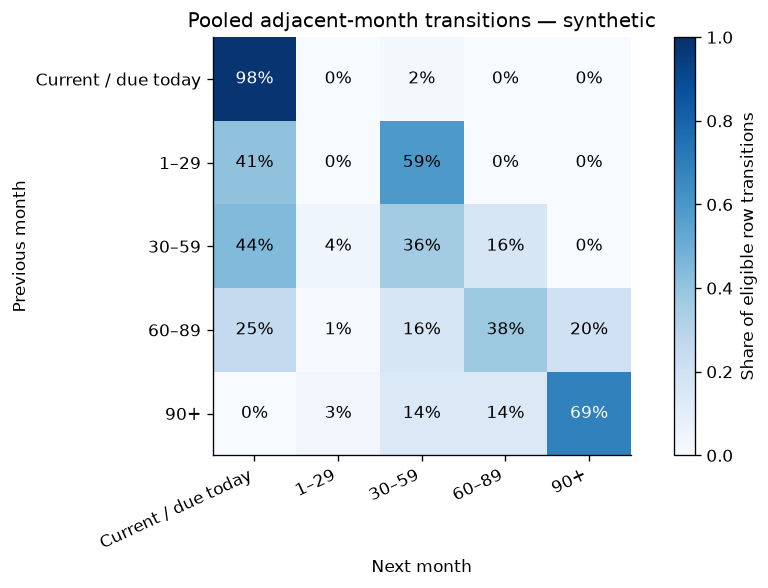

In [6]:
ordered = performance.sort_values(["loan_id", "observation_date"]).copy()
grouped = ordered.groupby("loan_id", sort=False)
ordered["previous_bucket"] = grouped.dpd_bucket.shift()
ordered["previous_mob"] = grouped.months_on_book.shift()
pairs = ordered.loc[(ordered.months_on_book - ordered.previous_mob).eq(1)]
counts = pd.crosstab(pairs.previous_bucket, pairs.dpd_bucket, dropna=False).reindex(index=BUCKETS, columns=BUCKETS, fill_value=0)
assert counts.to_numpy().sum() == len(performance) - N_LOANS
row_totals = counts.sum(axis=1)
transition = counts.div(row_totals.replace(0, np.nan), axis=0)
assert np.allclose(transition.loc[row_totals.gt(0)].sum(axis=1), 1)
display(counts)
fig, ax = plt.subplots(figsize=(8, 5))
heat = ax.imshow(transition.to_numpy(), vmin=0, vmax=1, cmap="Blues")
ax.set_xticks(range(len(BUCKETS)), BUCKETS, rotation=25, ha="right")
ax.set_yticks(range(len(BUCKETS)), BUCKETS)
ax.set(xlabel="Next month", ylabel="Previous month", title="Pooled adjacent-month transitions — synthetic")
for i in range(len(BUCKETS)):
    for j in range(len(BUCKETS)):
        val = transition.iloc[i, j]
        ax.text(j, i, "N/A" if pd.isna(val) else f"{val:.0%}", ha="center", va="center", color="white" if val > .6 else "black")
fig.colorbar(heat, ax=ax, label="Share of eligible row transitions")
fig.tight_layout()
fig.savefig(OUTPUT / "delinquency_transitions.png", bbox_inches="tight")
plt.show()

## 6. Vintage comparison at the same age
A newer loan has had less time to fall behind. Compare loans at a common **month on book (MOB)** rather than comparing lifetime outcomes at different ages.

We compare cumulative *ever 30+ DPD* at MOB 6 and MOB 12. Only loans old enough to have reached the selected MOB enter its denominator. Missing cells mean no eligible loans—not zero delinquency. Even age-matched comparisons still mix different calendar periods and scenario compositions; they are descriptive, not causal.

eligible_accounts  ever_dpd30_accounts  \
vintage months_on_book                                           
2024Q3  6                             174                   12   
        12                            174                   30   
2024Q4  6                             251                   27   
        12                            251                   50   
2025Q1  6                             227                   17   
        12                            227                   40   
2025Q2  6                             234                   25   
        12                            234                   43   
2025Q3  6                             219                   22   
        12                            141                   29   
2025Q4  6                             230                   20   
2026Q1  6                             165                   19   

                        ever_dpd30_rate  
vintage months_on_book                   
2024Q3  6                        0.0690  
        12                       0.1724  
2024Q4  6                        0.1076  
        12                       0.1992  
2025Q1  6                        0.0749  
        12                       0.1762  
2025Q2  6                        0.1068  
        12                       0.1838  
2025Q3  6                        0.1005  
        12                       0.2057  
2025Q4  6                        0.0870  
2026Q1  6                        0.1152

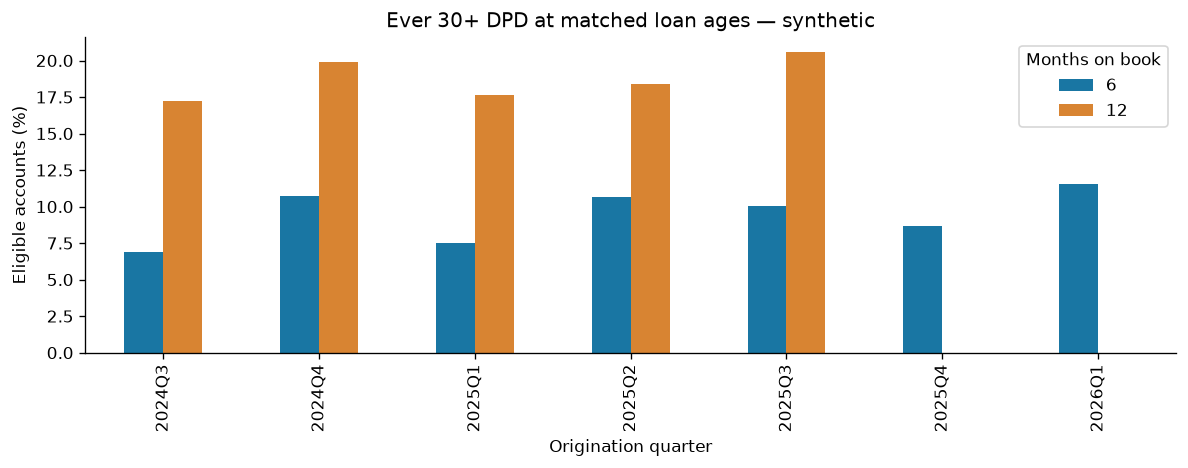

In [7]:
ordered["ever_dpd30"] = ordered.dpd.ge(30).groupby(ordered.loan_id).cummax()
vintage_rows = ordered.merge(loans[["loan_id", "origination_date"]], on="loan_id", validate="many_to_one")
vintage_rows["vintage"] = vintage_rows.origination_date.dt.to_period("Q").astype(str)
vintage = vintage_rows.loc[vintage_rows.months_on_book.isin([6, 12])].groupby(
    ["vintage", "months_on_book"], observed=True).agg(
    eligible_accounts=("loan_id", "size"), ever_dpd30_accounts=("ever_dpd30", "sum"))
vintage["ever_dpd30_rate"] = vintage.ever_dpd30_accounts / vintage.eligible_accounts
assert vintage.ever_dpd30_rate.between(0, 1).all()
assert vintage.xs(6, level="months_on_book").eligible_accounts.sum() == N_LOANS
eligible_12 = performance.loc[performance.observation_date.eq(AS_OF), "months_on_book"].ge(12).sum()
assert vintage.xs(12, level="months_on_book").eligible_accounts.sum() == eligible_12
display(vintage.round(4))
ax = vintage.ever_dpd30_rate.unstack().mul(100).plot.bar(figsize=(10, 4), color=["#1976A3", "#D88432"])
ax.set(title="Ever 30+ DPD at matched loan ages — synthetic", xlabel="Origination quarter", ylabel="Eligible accounts (%)")
ax.legend(title="Months on book")
plt.tight_layout()
plt.savefig(OUTPUT / "vintage_comparison.png", bbox_inches="tight")
plt.show()

## 7. Export and document
Two CSV tables form the dataset. `loan_id` is the join key, while `(loan_id, observation_date)` uniquely identifies a monthly record. The schema file gives units and caveats for every column. The manifest records settings, environment versions, and checksums.

All data are synthetic. A public Kaggle dataset made from these outputs should carry the **Synthetic** tag. Never replace these files with private customer records.

In [8]:
schema = {
    "loans.csv": {
        "loan_id": "Unique fictional loan identifier; no relationship to a real person.",
        "origination_date": "YYYY-MM-DD month-end; first installment due at following month-end.",
        "segment": "Hand-set payment-probability scenario A/B/C, not a real risk grade.",
        "principal_usd": "Original contractual principal, fictional USD.",
        "annual_rate": "Nominal annual interest rate as a fraction; monthly rate = annual_rate / 12; excludes fees.",
        "term_months": "Number of contractual monthly installments (36, 48 or 60).",
        "monthly_payment_usd": "Unrounded level contractual installment, fictional USD."
    },
    "monthly_performance.csv": {
        "loan_id": "Foreign key to loans.csv.",
        "observation_date": "YYYY-MM-DD month-end snapshot after this month's simulated payment.",
        "months_on_book": "Installments scheduled since origination, starting at 1.",
        "installments_paid": "Whole installments paid this month, allocated oldest first; integer 0–3.",
        "payment_received_usd": "installments_paid * contractual monthly payment; fictional USD.",
        "unpaid_installments": "Count of installments remaining unpaid after allocation, including amounts due today.",
        "oldest_unpaid_due_date": "Oldest unpaid due date, YYYY-MM-DD; blank only when queue is empty.",
        "overdue_scheduled_amount_usd": "Unpaid installment count * payment; includes newly due amount. No late fees or penalty interest.",
        "dpd": "Calendar days since oldest unpaid due date; zero when current or only today's installment is unpaid.",
        "scheduled_principal_usd": "Contractual principal assuming all installments were paid on time; NOT actual principal balance.",
        "dpd_bucket": "Current / due today, 1–29, 30–59, 60–89, or 90+ calendar days."
    }
}
loans.to_csv(OUTPUT / "loans.csv", index=False, date_format="%Y-%m-%d", float_format="%.10f")
performance.to_csv(OUTPUT / "monthly_performance.csv", index=False, date_format="%Y-%m-%d", float_format="%.10f")
(OUTPUT / "data_dictionary.json").write_text(json.dumps(schema, indent=2), encoding="utf-8")
for filename, columns in schema.items():
    loaded = pd.read_csv(OUTPUT / filename)
    assert loaded.columns.tolist() == list(columns)
    assert len(loaded) == (len(loans) if filename == "loans.csv" else len(performance))
manifest = {"synthetic": True, "seed": SEED, "loan_count": N_LOANS, "cutoff": str(AS_OF.date()),
            "monthly_rows": len(performance), "license": "CC0-1.0",
            "versions": {"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__, "matplotlib": matplotlib.__version__},
            "sha256": {name: hashlib.sha256((OUTPUT / name).read_bytes()).hexdigest() for name in schema}}
(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
print(json.dumps(manifest, indent=2))
print("PASS: notebook completed; exports passed schema and row-count checks.")

{
  "synthetic": true,
  "seed": 20260922,
  "loan_count": 1500,
  "cutoff": "2026-08-31",
  "monthly_rows": 22743,
  "license": "CC0-1.0",
  "versions": {
    "python": "3.14.7",
    "numpy": "2.5.3",
    "pandas": "3.0.6",
    "matplotlib": "3.11.2"
  },
  "sha256": {
    "loans.csv": "c1625f9f46d0f0dbbabc08281ee1d73e603060ded3d3fd088e8308c9511cf7f5",
    "monthly_performance.csv": "e5860bc6af994595396fe31f17128f760e07cbb4b423800a3f6677d67c672405"
  }
}
PASS: notebook completed; exports passed schema and row-count checks.


## Exercises and next steps
- Change the catch-up payment probability. Does curing improve before the 30+ DPD rate falls? Rerun all cells; explain the lag.
- Compare the cutoff account rate with the scheduled-weighted proxy. Identify which loan sizes explain the gap.
- Compare vintage cohorts at MOB 6 with a naive all-history comparison. Explain why exposure time changes the conclusion.
- Add partial payments using an amount-based FIFO queue. Extend the conservation tests before trusting the resulting DPD.
- For a future predictive model, define a fixed forward outcome window and separate observation-time features from future outcomes. Do not randomly split monthly rows from the same loan across train and test. Do not use future DPD, the target window's payments, or simulator parameters as deployable features.

### Limits worth carrying into your own projects
There are no closed accounts or charge-offs in this simulation; all contracts remain active. Payment patterns are simplified and scenario-driven. No protected attributes or real borrower profiles are represented, so this is not a fairness benchmark. Portfolio rates are properties of this generator, not financial forecasts.

### References
- [NumPy random Generator](https://numpy.org/doc/stable/reference/random/generator.html)
- [pandas groupby documentation](https://pandas.pydata.org/docs/user_guide/groupby.html)
- [Kaggle notebook documentation](https://www.kaggle.com/docs/notebooks)
- [Kaggle community guidelines: synthetic dataset etiquette](https://www.kaggle.com/community-guidelines)
- [CC0 1.0](https://creativecommons.org/publicdomain/zero/1.0/)